## 필수 library 설치 및 import

In [ ]:
!pip install mysql-connector-python pandas matplotlib
# mysql.connector.connect 실행 중 프로그램이 특별한 출력 없이 종료된다면, mysql-connector-python==9.0.0 설치


In [ ]:
import mysql.connector
import sys
import pandas as pd


## database 연결 정보 입력

In [ ]:
# Connect to the database
host = "astronaut.snu.ac.kr" # database 를 생성/연결할 서버 IP
port = "7007"
user = ""
password = ""
database = ""

# 이 셀을 다시 실행할 때 이전 연결이 서버에 남아 DROP/get_dump 가 멈추는 것을 방지
if "cur" in globals():
    try:
        cur.close()
    except Exception:
        pass
if "mysql_con" in globals():
    try:
        mysql_con.close()
    except Exception:
        pass

# mysql 을 서버에서 활용할 수 있도록 연결해준다.
mysql_con = mysql.connector.connect(
        host=host,
        port=port,
        user=user,
        password=password,
        database=database,
        autocommit=True
    )

# Cursor 를 통해 서버의 database 와 커뮤니케이트 한다.
cur = mysql_con.cursor(dictionary=True) # dictionary


## load SQL Dump file

Database에 실제 데이터가 담긴 table을 저장한다.

In [4]:
# mysql_connector 로 호스트의 mysql 서버와 연결한 후 
# table 데이터가 담긴 .sql file 을 읽어와 
# 호스트에 database 를 생성하고 필요한 table 을 생성한다.

def get_dump(mysql_con, filename):

    query = ""
    try:
        with mysql_con.cursor() as cursor: # cursor 선언
            # 재실행 시 FK 때문에 DROP이 막히지 않도록, dump 동안만 외래키 검사를 해제한다.
            for line in open(filename, 'r', encoding='utf8'): # .sql 파일 열기
                if line.strip():
                    line = line.strip()

                    # query 를 끝마치는 ";" 가 등장하기 전까지 파일을 읽으며 query 라는 변수에 저장 후 cursor 을 통해 서버의 database 로 송출
                    if line[-1] == ";":
                        query += line
                        cursor.execute(query) # 서버의 database 로 보냄
                        query = ""
                    else:
                        query += line

    except Warning as warn:
        print(warn)
        sys.exit()

get_dump(mysql_con, 'olist_database.sql')


In [5]:
# test connection
query = "SHOW tables;"     # 서버의 database 에 보내고 싶은 sql query
cur.execute(query)         # cur.execute() 을 통해 query 를 서버로 송출
a = cur.fetchall()         # cur.fetchall() 을 통해 query 실행 후 결과값 반환
print(a)


[{'Tables_in_DB97': 'customer'}, {'Tables_in_DB97': 'order_item'}, {'Tables_in_DB97': 'order_payment'}, {'Tables_in_DB97': 'order_review'}, {'Tables_in_DB97': 'orders'}, {'Tables_in_DB97': 'product'}, {'Tables_in_DB97': 'seller'}]


## Python for SQL

Python 라이브러리를 활용해 연결된 database에서 SQL query를 실행하고 그 결과를 반환한다.

In [6]:
"""
    get_output(query): SQL query 를 받아 해당 query를 연결된 database로 보내고, 
    그 결과 값을 dataframe으로 저장해 반환
"""
def get_output(query):
    cur.execute(query)
    out = cur.fetchall()
    df = pd.DataFrame(out)
    return df


**Connection Test**: 테이블에 들어있는 정보를 확인한다.




In [7]:
# test connection: orders 테이블 컬럼 확인
query = "SHOW COLUMNS FROM orders;"
get_output(query)


,Field,Type,Null,Key,Default,Extra
0,order_id,varchar(32),NO,PRI,None,
1,customer_id,varchar(32),NO,MUL,None,
2,order_status,varchar(11),NO,,None,
3,order_purchase_timestamp,datetime,NO,,None,
4,order_approved_at,datetime,YES,,None,
5,order_delivered_carrier_date,datetime,YES,,None,
6,order_delivered_customer_date,datetime,YES,,None,
7,order_estimated_delivery_date,datetime,NO,,None,


**Tip: Long SQL Queries in Python**

Python에서 triple quote(`"""..."""`)로 문자열을 작성하면 
단일 문자열을 여러 줄에 걸쳐 쓸 수 있어서 긴 SQL문도 읽기 쉽게 표현 가능하다.


In [8]:
query = """SELECT *
         FROM table1 JOIN table2 USING (col3)
         WHERE condition
         GROUP BY col3
         HAVING condition;"""
print(query)


SELECT *
         FROM table1 JOIN table2 USING (col3)
         WHERE condition
         GROUP BY col3
         HAVING condition;


## Python을 활용한 SQL query 실행 결과 분석


Python을 활용해 SQL문 실행 결과를 확인·변환·시각화한다.


In [9]:
query = "SELECT payment_type, payment_value FROM order_payment LIMIT 5;"
df = get_output(query)
df


,payment_type,payment_value
0,credit_card,184.03
1,credit_card,70.88
2,boleto,203.67
3,credit_card,83.69
4,credit_card,74.18


### pandas DataFrame의 기능

**특정 column 선택**: `df['column_a']`, `df[['column_a','column_b']]` 등 column 명을 이용해 특정 column의 데이터 확인 가능.
**특정 row 선택**: `df.iloc[0]`, `df.iloc[0:3]` 등 row index를 이용해 특정 row의 데이터 확인 가능.


In [10]:
print(df['payment_value'] )                   # 한 column
print()
print()
print(df[['payment_type', 'payment_value']])  # 여러 column


0    184.03
1     70.88
2    203.67
3     83.69
4     74.18
Name: payment_value, dtype: float64


  payment_type  payment_value
0  credit_card         184.03
1  credit_card          70.88
2       boleto         203.67
3  credit_card          83.69
4  credit_card          74.18


In [11]:
print(df.iloc[0] )   # 한 row
print()
print()
print(df.iloc[0:3])  # 여러 row

payment_type     credit_card
payment_value         184.03
Name: 0, dtype: object


  payment_type  payment_value
0  credit_card         184.03
1  credit_card          70.88
2       boleto         203.67


**데이터를 N개만 선택**

- `.head()`는 python dataframe에서 N개의 row만 가져오는 방식
- SQL문을 작성할 때 `"LIMIT N"` 구문을 활용하면 SQL 쿼리 단계에서 앞에서부터 N개의 row만 포함


In [12]:
query = "SELECT * FROM customer;"
get_output(query).head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,005092c23e81812fbbe11fc6cf7e5316,38827a4b81c4d81cffaec1accef6572c,8223,sao paulo,SP
1,006431d77c665533ac99b501d8a6ab06,2666a61d9b5755651665549f80bb3450,12230,sao jose dos campos,SP
2,00e7c822a5cd0647e9251fc711276ea7,7c438259d88d8eefb977be5432d761c1,35500,divinopolis,MG
3,01311fef2cb7553344ac33c95e196db1,d49e0879143741c88dcef7eaee470554,28010,campos dos goytacazes,RJ
4,0138bea323fc76e6968c0fa28a35d9e8,513d16da25fe4a05a17d556b9a62e2ae,9195,santo andre,SP


In [13]:
query = "SELECT * FROM customer LIMIT 5;"  # 위와 같은 결과
get_output(query)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,005092c23e81812fbbe11fc6cf7e5316,38827a4b81c4d81cffaec1accef6572c,8223,sao paulo,SP
1,006431d77c665533ac99b501d8a6ab06,2666a61d9b5755651665549f80bb3450,12230,sao jose dos campos,SP
2,00e7c822a5cd0647e9251fc711276ea7,7c438259d88d8eefb977be5432d761c1,35500,divinopolis,MG
3,01311fef2cb7553344ac33c95e196db1,d49e0879143741c88dcef7eaee470554,28010,campos dos goytacazes,RJ
4,0138bea323fc76e6968c0fa28a35d9e8,513d16da25fe4a05a17d556b9a62e2ae,9195,santo andre,SP


**`.shape`**: 전체 데이터를 (행 개수, 열 개수) tuple을 반환.


In [14]:
df.shape  # (행 개수, 열 개수)


(5, 2)

**`.dtypes`**: 각 컬럼의 자료형을 표시.


In [15]:
df.dtypes


payment_type         str
payment_value    float64
dtype: object

**`.describe()`**: 숫자 데이터를 담고 있는 열의 개수·평균·표준편차·최솟값·최댓값 등 주요 정보를 요약.


In [16]:
df.describe()


,payment_value
count,5.000000
mean,123.290000
std,64.955855
min,70.880000
25%,74.180000
50%,83.690000
75%,184.030000
max,203.670000


**`df.plot(...)`**: DataFrame의 데이터를 그래프로 시각화.

- `kind`: 그래프 종류
  - `'bar'`: 막대그래프
  - `'barh'`: 가로 막대그래프
  - `'hist'`: 히스토그램
  - `'line'`: 선그래프
  - `'scatter'`: 산점도
  - `'pie'`: 원그래프
- `x`, `y`: 축에 쓸 컬럼 (`y`에 여러 column의 list를 입력하면 여러 그래프를 한꺼번에 그릴 수 있음)
- `title`, `xlabel`, `ylabel`: 제목/x축/y축 이름
- `rot`: x축 눈금 글자 회전 각도 (예: `rot=45`)
- `marker`: 선그래프에서 점 모양 (예: `marker='o'`)
- ...


<Axes: title={'center': 'Payment count by type'}, xlabel='payment_type', ylabel='payment_count'>

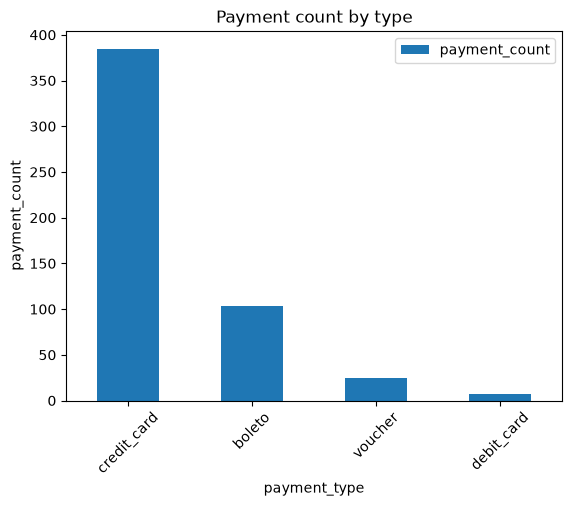

In [17]:
# 간단한 사용 예시
query = """SELECT payment_type, COUNT(*) AS payment_count
           FROM order_payment
           GROUP BY payment_type;"""
df = get_output(query)

df.plot(kind='bar', x='payment_type', y='payment_count',
        title='Payment count by type',
        xlabel='payment_type', ylabel='payment_count', rot=45)


## Python for SQL 예제


**Question 1**: 데이터 탐색

아래 SQL로 `order_payment` 테이블을 가져온 뒤, pandas로 다음을 확인하시오.

1. 행·열 개수
2. 각 컬럼 자료형
3. 첫 5행의 데이터
4. (선택) 숫자/요약이 가능한 열이 있다면 `.describe()`


In [18]:
query = "SELECT * FROM order_payment;"
df = get_output(query)

print(df.shape)
print(df.dtypes)
print(df.head())
df.describe()


(520, 4)
order_id                  str
payment_sequential      int64
payment_type              str
payment_value         float64
dtype: object
                           order_id  payment_sequential payment_type  \
0  00858d03144cc35cfd1dd043647e7c88                   1  credit_card   
1  008ce8764db2e397e153000e017475b6                   1  credit_card   
2  00d85bfe0e28c91b69d0fe1f29255a31                   1       boleto   
3  019aaee09698daf81dcffe9d94a18b5c                   1  credit_card   
4  01bc343311e5b8090b64d6ab287a5cf0                   1  credit_card   

   payment_value  
0         184.03  
1          70.88  
2         203.67  
3          83.69  
4          74.18  


,payment_sequential,payment_value
count,520.000000,520.000000
mean,1.075000,175.230519
std,0.464698,229.140728
min,1.000000,0.430000
25%,1.000000,64.082500
50%,1.000000,111.160000
75%,1.000000,188.327500
max,7.000000,2039.200000


**Question 2**: 가격대별 상품 가짓수 분포

`order_item`에 기록된 각 상품의 가격 정보(`price`)를 이용해 가격대별 상품 가짓수 분포 (`kind='hist'`)를 그리시오.

Hint: `plot(kind='hist')`에서 `bins` 인자를 통해 가로축을 몇 개 구간으로 나눌지 설정할 수 있다. (기본값: 10)


                         product_id   price
0  e40fa115d27ea4a80bf2136d5f0cfcd7  165.00
1  52a8061c8e8e8cea30b41344aac26431   43.49
2  fb8e60e1a3c247d3a2e17f6986e71a40  189.90
3  b00a32a0b42fd65efb58a5822009f629   75.90
4  c8c969c3a6423f48df9fde8a13e6770b   21.99


<Axes: title={'center': 'Price distribution'}, xlabel='price', ylabel='count'>

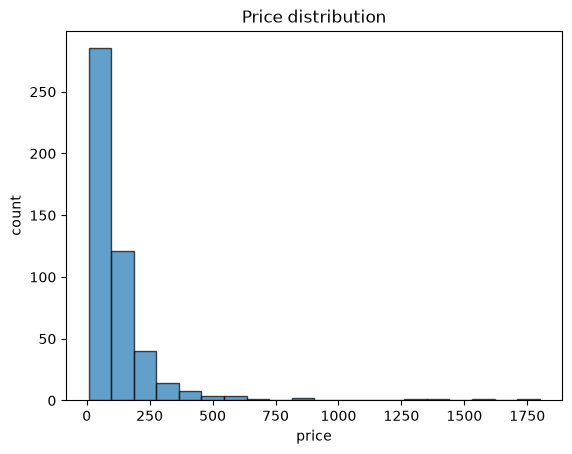

In [ ]:
query = "SELECT DISTINCT product_id, price FROM order_item;"
df = get_output(query)
print(df.head())

df['price'].plot()


**Question 3**: 결제수단별 결제 건수 및 총 결제 금액

아래 SQL은 결제수단(`payment_type`)별 **건수**와 **총 결제 금액**을 집계한 것이다.
결과를 DataFrame으로 받은 뒤,

1. `payment_count`를 막대그래프(`kind='bar'`)로 시각화하고
2. `total_payment_value`도 막대그래프로 그려 비교하시오.


  payment_type  payment_count  total_payment_value
0  credit_card            385             72301.22
1       boleto            103             17014.17
2      voucher             25              1344.59
3   debit_card              7               459.89


<Axes: title={'center': 'Total payment value by type'}, xlabel='payment_type', ylabel='total_payment_value'>

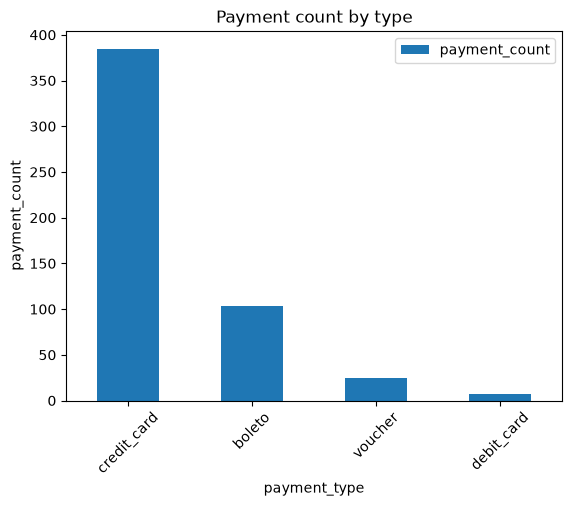

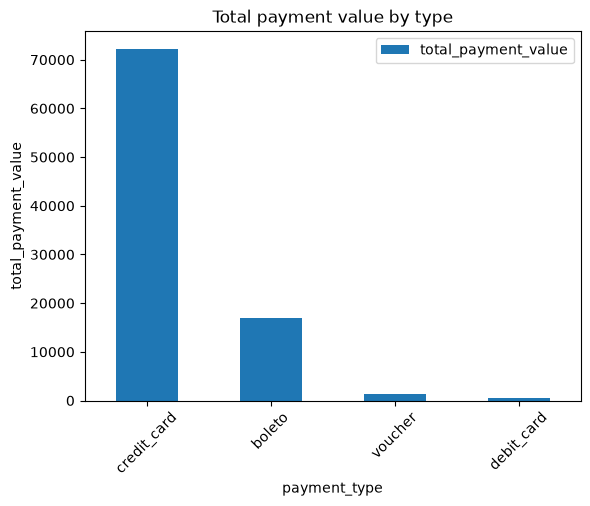

In [ ]:
query = """SELECT payment_type,
                  COUNT(*) AS payment_count,
                  SUM(payment_value) AS total_payment_value
           FROM order_payment
           GROUP BY payment_type
           ORDER BY total_payment_value DESC;"""
df = get_output(query)
print(df)

df.plot()

df.plot()


**Question 4**: 월별 주문 수 및 총 결제 금액

아래 SQL은 월별 **고유 주문 수**와 **총 결제 금액**을 집계한다.

결과를 받은 뒤 주문 수와 총 결제 금액의 월별 추이를 각각 선그래프(`kind='line'`, `marker='o'`)로 그리시오.


    month  num_orders  total_payment
0       1          37        6448.32
1       2          41        6618.46
2       3          38        8745.59
3       4          53       11731.73
4       5          61       11939.73
5       6          50        8291.47
6       7          54        7526.42
7       8          58       10327.19
8       9          19        2764.45
9      10          26        3522.24
10     11          41        9221.65
11     12          21        3982.62


<Axes: title={'center': 'Total payment by month'}, xlabel='month', ylabel='total_payment'>

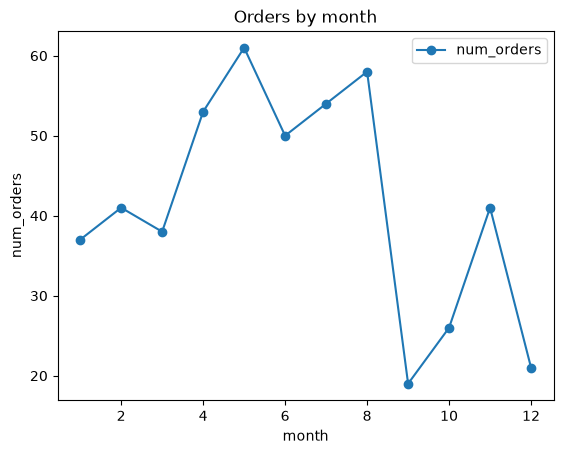

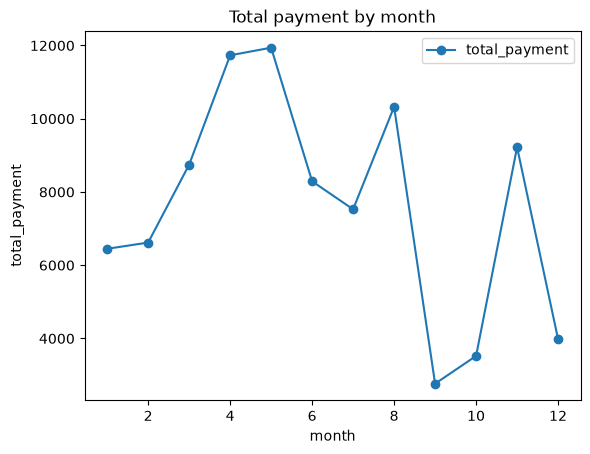

In [ ]:
query = """SELECT MONTH(o.order_purchase_timestamp) AS month,
                  COUNT(DISTINCT o.order_id) AS num_orders,
                  SUM(op.payment_value) AS total_payment
           FROM orders o
           JOIN order_payment op ON o.order_id = op.order_id
           GROUP BY month
           ORDER BY month;"""
df = get_output(query)
print(df)

df.plot()

df.plot()


**Question 5**: 리뷰 점수별 결제 금액의 평균·최소·최댓값

아래 SQL은 리뷰 점수(`review_score`)별 리뷰 건수와 결제 금액의 평균·최소·최댓값을 집계한다.

월별 평균값(`avg_payment`), 최솟값(`min_payment`), 최댓값(`max_payment`)을 비교하는 막대그래프를 그리시오.


   review_score  avg_payment  min_payment  max_payment
0             1   181.480270        13.42      1525.78
1             2   170.759286        62.10       485.29
2             3   179.486000        29.13      1087.44
3             4   207.773982         0.43      2039.20
4             5   158.328143         2.87      1657.57


<Axes: title={'center': 'Payment stats by review score'}, xlabel='review_score', ylabel='payment_value'>

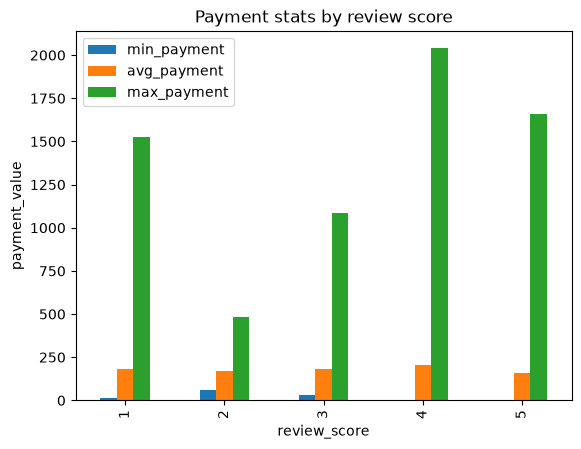

In [ ]:
query = """SELECT r.review_score,
                  AVG(p.payment_value) AS avg_payment,
                  MIN(p.payment_value) AS min_payment,
                  MAX(p.payment_value) AS max_payment
           FROM order_review r
           JOIN order_payment p ON r.order_id = p.order_id
           GROUP BY r.review_score
           ORDER BY r.review_score;"""
df = get_output(query)
print(df)

df.plot()